In [2]:
import pandas as pd
import numpy as np
import requests

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 24.86,
    "longitude": 67.01,
    "start_date": "2015-01-01",
    "end_date": "2025-12-31",
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "windspeed_10m_max",
        "relative_humidity_2m_mean",
        "surface_pressure_mean",
    ],
    "timezone": "auto"
}

response = requests.get(url, params=params)
print(response.status_code)

data = response.json()
df = pd.DataFrame(data["daily"])
df.to_csv("weather_raw.csv", index=False)
df.head()

200


,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean,surface_pressure_mean
0,2015-01-01,22.4,14.0,17.8,0.0,34.0,49,1015.8
1,2015-01-02,24.9,15.3,19.5,0.0,21.5,50,1016.2
2,2015-01-03,24.6,13.1,19.1,0.0,15.1,58,1015.9
3,2015-01-04,25.5,13.1,19.7,0.0,12.0,66,1016.5
4,2015-01-05,25.5,14.6,19.8,0.0,14.8,66,1016.6


In [3]:
df = pd.read_csv("weather_raw.csv")
print(df.shape)
df.info()

(4018, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time                       4018 non-null   str    
 1   temperature_2m_max         4018 non-null   float64
 2   temperature_2m_min         4018 non-null   float64
 3   temperature_2m_mean        4018 non-null   float64
 4   precipitation_sum          4018 non-null   float64
 5   windspeed_10m_max          4018 non-null   float64
 6   relative_humidity_2m_mean  4018 non-null   int64  
 7   surface_pressure_mean      4018 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 251.3 KB


In [4]:
df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")
df.head()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean,surface_pressure_mean
time,,,,,,,
2015-01-01,22.4,14.0,17.8,0.0,34.0,49,1015.8
2015-01-02,24.9,15.3,19.5,0.0,21.5,50,1016.2
2015-01-03,24.6,13.1,19.1,0.0,15.1,58,1015.9
2015-01-04,25.5,13.1,19.7,0.0,12.0,66,1016.5
2015-01-05,25.5,14.6,19.8,0.0,14.8,66,1016.6


In [5]:
df.columns = ["temp_max", "temp_min", "temp_mean", "rain", "wind_max", "humidity", "pressure"]
df.head()

,temp_max,temp_min,temp_mean,rain,wind_max,humidity,pressure
time,,,,,,,
2015-01-01,22.4,14.0,17.8,0.0,34.0,49,1015.8
2015-01-02,24.9,15.3,19.5,0.0,21.5,50,1016.2
2015-01-03,24.6,13.1,19.1,0.0,15.1,58,1015.9
2015-01-04,25.5,13.1,19.7,0.0,12.0,66,1016.5
2015-01-05,25.5,14.6,19.8,0.0,14.8,66,1016.6


In [6]:
print(df.isnull().sum())
print("Duplicate dates:", df.index.duplicated().sum())

temp_max     0
temp_min     0
temp_mean    0
rain         0
wind_max     0
humidity     0
pressure     0
dtype: int64
Duplicate dates: 0


In [7]:
df.describe()

,temp_max,temp_min,temp_mean,rain,wind_max,humidity,pressure
count,4018.00000,4018.000000,4018.000000,4018.000000,4018.000000,4018.000000,4018.000000
mean,30.23900,22.876307,26.217148,0.702265,23.394998,67.690891,1007.688477
std,3.54719,5.050256,3.946835,6.559459,6.729938,15.281168,6.625093
min,18.90000,8.900000,14.700000,0.000000,7.700000,14.000000,991.900000
25%,28.20000,18.800000,23.200000,0.000000,18.600000,59.000000,1002.225000
50%,30.70000,24.600000,27.600000,0.000000,23.000000,74.000000,1007.900000
75%,32.50000,27.100000,29.300000,0.000000,27.975000,79.000000,1013.400000
max,42.90000,32.300000,37.600000,304.900000,48.000000,92.000000,1021.800000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

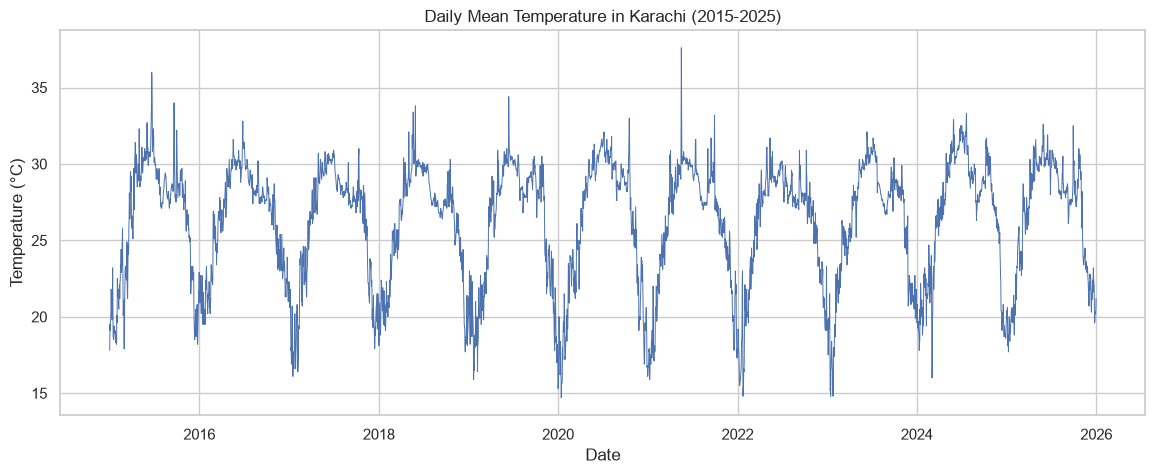

In [9]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df["temp_mean"], linewidth=0.7)
plt.title("Daily Mean Temperature in Karachi (2015-2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

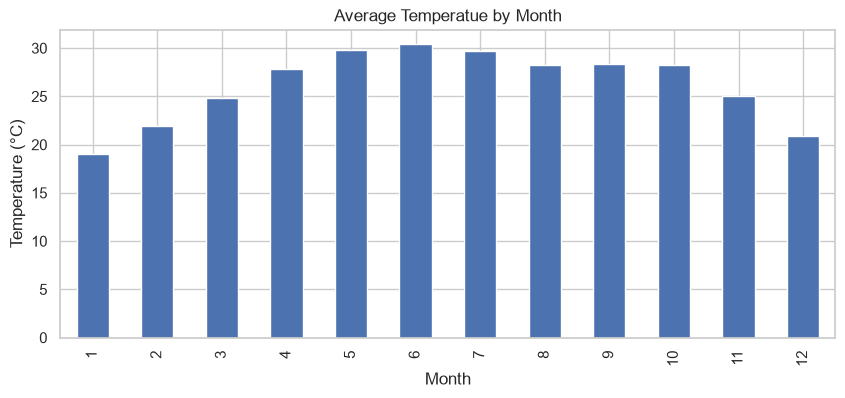

In [10]:
monthly = df.groupby(df.index.month)["temp_mean"].mean()

plt.figure(figsize=(10,4))
monthly.plot(kind="bar")
plt.title("Average Temperatue by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

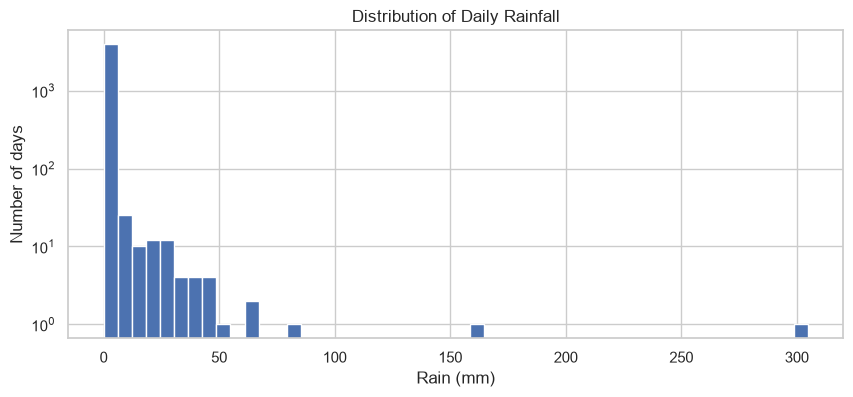

In [11]:
plt.figure(figsize=(10,4))
plt.hist(df["rain"], bins=50)
plt.title("Distribution of Daily Rainfall")
plt.xlabel("Rain (mm)")
plt.ylabel("Number of days")
plt.yscale("log")
plt.show()

In [12]:
df.sort_values("rain", ascending=False).head(5)

,temp_max,temp_min,temp_mean,rain,wind_max,humidity,pressure
time,,,,,,,
2019-08-11,27.3,26.2,26.8,304.9,42.8,91,993.0
2022-07-24,28.9,26.7,27.6,162.3,30.3,88,998.0
2022-08-12,30.3,25.8,28.1,82.7,40.5,86,993.6
2025-09-09,27.9,25.5,26.1,64.4,21.0,92,1002.5
2022-07-25,28.6,25.9,27.4,62.1,23.6,89,998.3


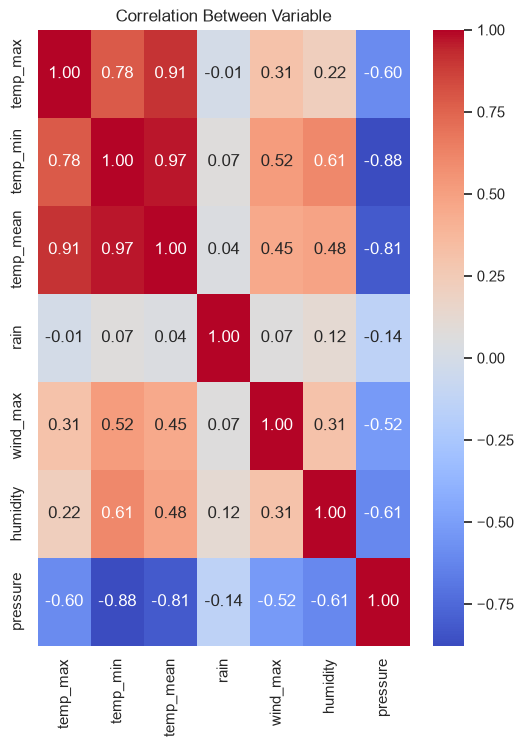

In [13]:
plt.figure(figsize=(6,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Variable")
plt.show()

In [14]:
df["target"] = df["temp_mean"].shift(-1)
df[["temp_mean", "target"]].head()

,temp_mean,target
time,,
2015-01-01,17.8,19.5
2015-01-02,19.5,19.1
2015-01-03,19.1,19.7
2015-01-04,19.7,19.8
2015-01-05,19.8,20.4


In [15]:
cols = ["temp_mean", "temp_max", "temp_min", "rain", "humidity", "pressure", "wind_max"]

for lag in [1, 2, 3]:
    for col in cols:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df.head()

,temp_max,temp_min,temp_mean,rain,wind_max,humidity,pressure,target,temp_mean_lag1,temp_max_lag1,...,humidity_lag2,pressure_lag2,wind_max_lag2,temp_mean_lag3,temp_max_lag3,temp_min_lag3,rain_lag3,humidity_lag3,pressure_lag3,wind_max_lag3
time,,,,,,,,,,,,,,,,,,,,,
2015-01-01,22.4,14.0,17.8,0.0,34.0,49,1015.8,19.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,24.9,15.3,19.5,0.0,21.5,50,1016.2,19.1,17.8,22.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03,24.6,13.1,19.1,0.0,15.1,58,1015.9,19.7,19.5,24.9,...,49.0,1015.8,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-04,25.5,13.1,19.7,0.0,12.0,66,1016.5,19.8,19.1,24.6,...,50.0,1016.2,21.5,17.8,22.4,14.0,0.0,49.0,1015.8,34.0
2015-01-05,25.5,14.6,19.8,0.0,14.8,66,1016.6,20.4,19.7,25.5,...,58.0,1015.9,15.1,19.5,24.9,15.3,0.0,50.0,1016.2,21.5


In [16]:
df["temp_roll7"] = df["temp_mean"].rolling(7).mean()
df["pressure_change"] = df["pressure"].diff()

In [17]:
day_of_year = df.index.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365)
df["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365)

In [18]:
print("Before:", df.shape)
df = df.dropna()
print("After:", df.shape)

Before: (4018, 33)
After: (4011, 33)


In [19]:
X = df.drop(columns=["target"])
y = df["target"]

split_date = "2023-01-01"

X_train, X_test = X[X.index < split_date], X[X.index >= split_date]
y_train, y_test = y[y.index < split_date], y[y.index >= split_date]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train period:", X_train.index.min().date(), "to", X_train.index.max().date())
print("Test period:", X_test.index.min().date(), "to", X_test.index.max().date())

Train: (2916, 32) | Test: (1095, 32)
Train period: 2015-01-07 to 2022-12-31
Test period: 2023-01-01 to 2025-12-30


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} MAE: {mae:.2f}°C | RMSE: {rmse:.2f}°C  | R²: {r2:.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

In [21]:
results = []

y_pred_base = X_test["temp_mean"]
results.append(evaluate("Baseline (persistence)", y_test, y_pred_base))

Baseline (persistence) MAE: 0.52°C | RMSE: 0.76°C  | R²: 0.963


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))

Linear Regression    MAE: 0.49°C | RMSE: 0.69°C  | R²: 0.970


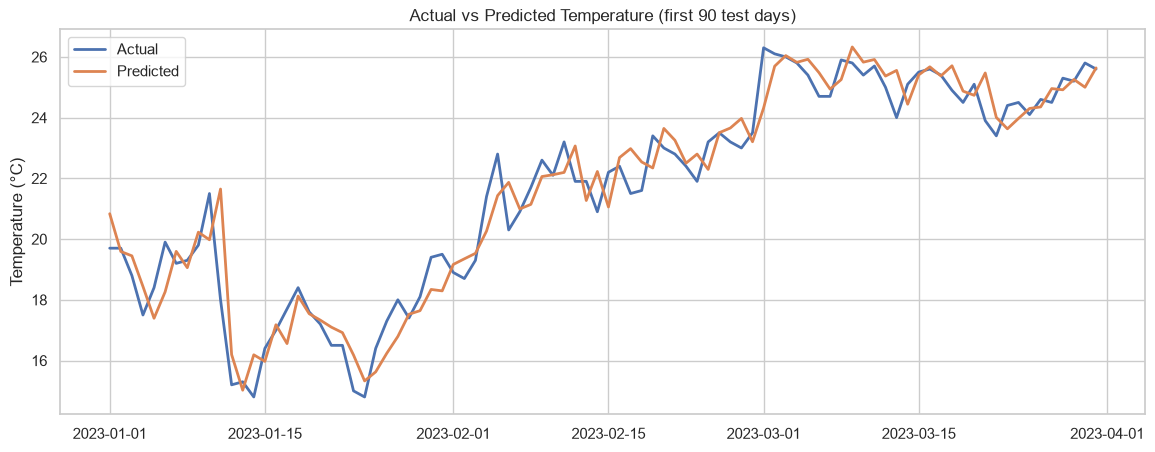

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:90], y_test.values[:90], label="Actual", linewidth=2)
plt.plot(y_test.index[:90], y_pred_lr[:90], label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Temperature (first 90 test days)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [24]:
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print(coefs.head(10))

temp_mean         1.628844
doy_cos          -0.793662
temp_mean_lag1   -0.613438
temp_min         -0.430084
temp_min_lag1     0.216067
temp_max         -0.215399
temp_roll7        0.129397
temp_max_lag1     0.126378
temp_max_lag2     0.056013
temp_mean_lag3    0.046161
dtype: float64


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, y_pred_rf))

Random Forest        MAE: 0.52°C | RMSE: 0.74°C  | R²: 0.965


In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
results.append(evaluate("Gradient Boosting", y_test, y_pred_gb))

Gradient Boosting    MAE: 0.50°C | RMSE: 0.70°C  | R²: 0.968


In [33]:
results_df = pd.DataFrame(results).set_index("model").round(3)
results_df.sort_values("MAE")

,MAE,RMSE,R2
model,,,
Linear Regression,0.494,0.686,0.970
Gradient Boosting,0.502,0.705,0.968
Baseline (persistence),0.524,0.761,0.963
Random Forest,0.524,0.737,0.965


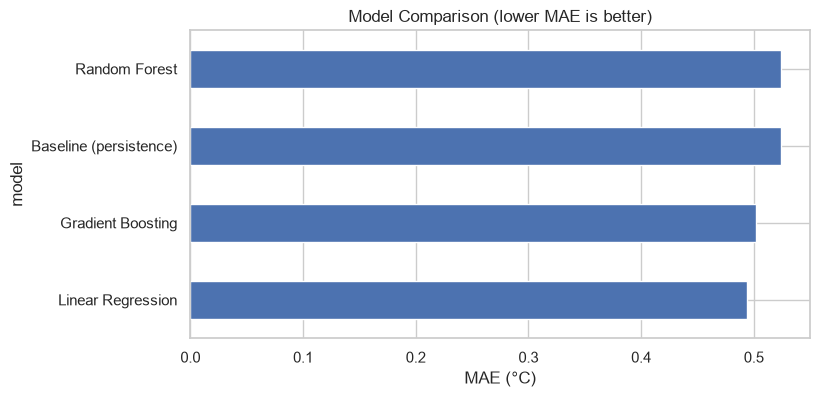

In [34]:
results_df["MAE"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Model Comparison (lower MAE is better)")
plt.xlabel("MAE (°C)")
plt.show()

In [35]:
importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

temp_mean         0.886659
temp_roll7        0.066233
doy_cos           0.017318
temp_mean_lag3    0.007195
temp_max          0.006740
humidity          0.004189
wind_max          0.001733
temp_max_lag2     0.001242
rain              0.001178
temp_max_lag1     0.001075
dtype: float64


In [36]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

temp_mean          0.963330
humidity           0.003547
doy_cos            0.002877
temp_max           0.002523
pressure_change    0.002070
wind_max           0.002058
humidity_lag1      0.001686
doy_sin            0.001661
temp_roll7         0.001375
temp_min           0.001331
dtype: float64


In [38]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
}

for name, model in models.items():
    scores = -cross_val_score(model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    print(f"{name:20s} MAE per fold: {scores.round(3)} | mean: {scores.mean():.3f}")

Linear Regression    MAE per fold: [0.498 0.553 0.538 0.483 0.487] | mean: 0.512
Random Forest        MAE per fold: [0.589 0.6   0.577 0.507 0.514] | mean: 0.558
Gradient Boosting    MAE per fold: [0.585 0.598 0.565 0.502 0.486] | mean: 0.547


In [41]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
results.append(evaluate("Ridge", y_test, y_pred_ridge))

Ridge                MAE: 0.51°C | RMSE: 0.71°C  | R²: 0.968


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3],
}

search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
y_pred_gbt = search.best_estimator_.predict(X_test)
results.append(evaluate("Gradient Boosting (tuned)", y_test, y_pred_gbt))

Best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 300}
Gradient Boosting (tuned) MAE: 0.50°C | RMSE: 0.70°C  | R²: 0.968


In [44]:
pd.DataFrame(results).set_index("model").round(3).sort_values("MAE")

,MAE,RMSE,R2
model,,,
Linear Regression,0.494,0.686,0.970
Gradient Boosting (tuned),0.497,0.702,0.968
Gradient Boosting,0.502,0.705,0.968
Ridge,0.508,0.707,0.968
Random Forest,0.524,0.737,0.965
Baseline (persistence),0.524,0.761,0.963


In [45]:
df["rain_next"] = df["rain"].shift(-1)
df_c = df.dropna(subset=["rain_next"]).copy()
df_c["rain_tomorrow"] = (df_c["rain_next"] > 1).astype(int)

print(df_c["rain_tomorrow"].value_counts())
print("Rainy day %:", round(df_c["rain_tomorrow"].mean() * 100, 1))

rain_tomorrow
0    3719
1     291
Name: count, dtype: int64
Rainy day %: 7.3


In [46]:
X_c = df_c.drop(columns=["target", "rain_next", "rain_tomorrow"])
y_c = df_c["rain_tomorrow"]
Xc_train, Xc_test = X_c[X_c.index < split_date], X_c[X_c.index >= split_date]
yc_train, yc_test = y_c[y_c.index < split_date], y_c[y_c.index >= split_date]

print(Xc_train.shape, Xc_test.shape)

(2916, 32) (1094, 32)


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

clf_results = []

def evaluate_clf(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    print(f"{name:25s} Acc: {acc:.3f} | Prec: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    clf_results.append({"model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc})

In [48]:
y_pred_nvr = np.zeros(len(yc_test), dtype=int)
evaluate_clf("Baseline (never rain)", yc_test, y_pred_nvr)

Baseline (never rain)     Acc: 0.909 | Prec: 0.000 | Recall: 0.000 | F1: 0.000 | AUC: nan


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logit = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000))
logit.fit(Xc_train, yc_train)
evaluate_clf("Logistic Regression", yc_test, logit.predict(Xc_test), logit.predict_proba(Xc_test)[:, 1])

rfc = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
rfc.fit(Xc_train, yc_train)
evaluate_clf("Random Forest", yc_test, rfc.predict(Xc_test), rfc.predict_proba(Xc_test)[:, 1])

Logistic Regression       Acc: 0.784 | Prec: 0.259 | Recall: 0.730 | F1: 0.382 | AUC: 0.860
Random Forest             Acc: 0.877 | Prec: 0.372 | Recall: 0.510 | F1: 0.430 | AUC: 0.872


In [50]:
pd.DataFrame(clf_results).set_index("model").round(3).sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,AUC
model,,,,,
Random Forest,0.877,0.372,0.51,0.430,0.872
Logistic Regression,0.784,0.259,0.73,0.382,0.860
Baseline (never rain),0.909,0.000,0.00,0.000,NaN


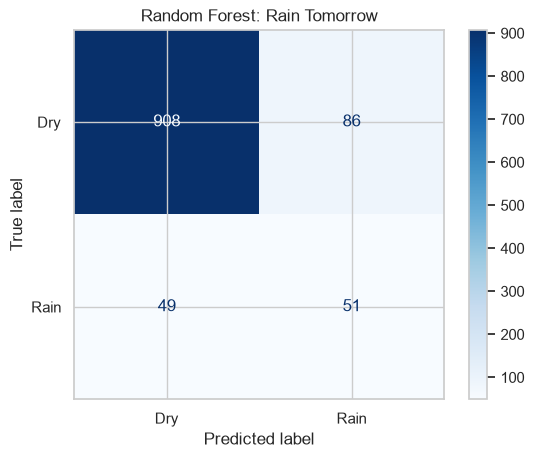

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rfc, Xc_test, yc_test, display_labels=["Dry", "Rain"], cmap="Blues")
plt.title("Random Forest: Rain Tomorrow")
plt.show()

In [54]:
probs = rfc.predict_proba(Xc_test)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (probs >= t).astype(int)
    p = precision_score(yc_test, pred, zero_division=0)
    r = recall_score(yc_test, pred, zero_division=0)
    print(f"threshold {t}: precision {p:.2f} | recall {r:.2f}")

threshold 0.3: precision 0.35 | recall 0.78
threshold 0.4: precision 0.37 | recall 0.65
threshold 0.5: precision 0.37 | recall 0.51
threshold 0.6: precision 0.41 | recall 0.45
threshold 0.7: precision 0.47 | recall 0.38


In [55]:
imp = pd.Series(rfc.feature_importances_, index=Xc_train.columns).sort_values(ascending=False)
print(imp.head(8))

rain             0.181253
pressure_lag1    0.081622
pressure         0.068093
rain_lag1        0.065389
pressure_lag2    0.063127
temp_min_lag3    0.041910
pressure_lag3    0.041455
temp_min_lag2    0.039937
dtype: float64


In [59]:
import joblib

final_temp = LinearRegression().fit(X, y)
final_rain = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_c, y_c)

joblib.dump(final_temp, "temp_model.pkl")
joblib.dump(final_rain, "rain_model.pkl")
print("Saved!")

Saved!


In [60]:
temp_model = joblib.load("temp_model.pkl")
rain_model = joblib.load("rain_model.pkl")

def predict_tomorrow(features_row):
    temp = temp_model.predict(features_row)[0]
    rain_prob = rain_model.predict_proba(features_row)[0, 1]
    print(f"Predicted mean temperature: {temp:.1f}°C")
    print(f"Chance of rain (>1 mm): {rain_prob * 100:.0f}%")

latest = X.iloc[[-1]]
print("Using data from:", latest.index[0].date())
predict_tomorrow(latest)

Using data from: 2025-12-30
Predicted mean temperature: 20.8°C
Chance of rain (>1 mm): 41%


In [61]:
base_cols = ["temp_max", "temp_min", "temp_mean", "rain", "wind_max", "humidity", "pressure"]
lag_cols = ["temp_mean", "temp_max", "temp_min", "rain", "humidity", "pressure", "wind_max"]

def make_features(raw):
    d = raw[base_cols].copy()
    for lag in [1, 2, 3]:
        for col in lag_cols:
            d[f"{col}_lag{lag}"] = d[col].shift(lag)
    d["temp_roll7"] = d["temp_mean"].rolling(7).mean()
    d["pressure_change"] = d["pressure"].diff()
    doy = d.index.dayofyear
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    return d

In [64]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 24.86,
    "longitude": 67.01,
    "past_days": 14,
    "forecast_days": 1,
    "daily": [
        "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
        "precipitation_sum", "windspeed_10m_max",
        "relative_humidity_2m_mean", "surface_pressure_mean",
    ],
    "timezone": "auto",
}

r = requests.get(url, params=params)
print(r.status_code)

recent = pd.DataFrame(r.json()["daily"])
recent["time"] = pd.to_datetime(recent["time"])
recent = recent.set_index("time")
recent.columns = base_cols
recent.tail()

200


,temp_max,temp_min,temp_mean,rain,wind_max,humidity,pressure
time,,,,,,,
2026-09-26,31.3,27.2,28.7,0.0,19.9,76,1004.7
2026-09-27,31.3,26.8,28.5,0.0,18.0,76,1004.9
2026-09-28,30.7,26.3,28.2,0.0,15.7,73,1006.8
2026-09-29,30.4,25.2,27.8,0.0,12.2,72,1011.0
2026-09-30,30.1,25.0,27.4,0.0,14.7,72,1012.1


In [65]:
feats = make_features(recent).dropna()[X.columns]
latest = feats.iloc[[-1]]

print("Using data from:", latest.index[0].date())
print(f"Predicted mean temp tomorrow: {temp_model.predict(latest)[0]:.1f}°C")
print(f"Rain score: {rain_model.predict_proba(latest)[0, 1]:.2f}")

Using data from: 2026-09-30
Predicted mean temp tomorrow: 27.5°C
Rain score: 0.04


In [66]:
check = make_features(df).dropna()[X.columns]
common = X.index.intersection(check.index)
print("Rows compared:", len(common))
print("Same features as before:", np.allclose(check.loc[common], X.loc[common]))

Rows compared: 4005
Same features as before: True


In [69]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import json
json.dump(list(X.columns), open("feature_columns.json", "w"))
print(len(X.columns), "columns saved")

32 columns saved
